# import

In [1]:
import sys
sys.path.append('..')
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

from collections import defaultdict
from typing import Optional, Union, Tuple
from joblib import Parallel, delayed
import numpy as np
from synth import gen_traj, postprocess_collisions, draw_ants_with_direction, draw_traj, build_visible_gt
from nmot import NMOT
from eval import evaluate_mot
from pathlib import Path
import pickle

# defs

In [2]:
def track(
    input_path: str,
    output_path: str = "tracked_output.mp4",
    csv_path: str = "tracks.csv",
    imshow=True,
    roi=None,
    dist2Threshold=50,
    knn_history = 100,
    pred_head = 'kalman',
    warmup_frames = 50
):
    if pred_head=='zero': pred_head=None
    
    cap = cv.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    fps = cap.get(cv.CAP_PROP_FPS)
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    if output_path is not None:
        fourcc = cv.VideoWriter_fourcc(*"mp4v")
        writer = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    tracker = NMOT(
        warmup_frames=warmup_frames,
        dist2Threshold=dist2Threshold,
        knn_history=knn_history,
        min_area=8,
        max_area=80,
        max_match_dist=25,
        max_missed=12,
        pred_head=pred_head,
        roi=roi,
    )

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        vis, mask, active_tracks = tracker.update(frame)
        if output_path is not None: 
            writer.write(vis)

        if imshow:
            # cv2.imshow('frame', frame)
            fig, ax = plt.subplots(nrows=2)
            fig.set_size_inches((20, 10))
            
            ax[0].imshow(vis)
            ax[1].imshow(mask)
            
            plt.show()
            
            clear_output(wait=True)
            if cv.waitKey(1) & 0xFF == 27:
                cv.destroyAllWindows()
                if output_path:
                    writer.release()
                break

    cap.release()
    if output_path is not None: 
        writer.release()
    cv.destroyAllWindows()
    if csv_path:
        df = tracker.save_tracks(csv_path)

    # return df

In [3]:
def gen(config:dict, output_vid_path:str, output_csv_path:str):
    
    trajectories = gen_traj(**config)

    traj_fixed = postprocess_collisions(
        trajectories,
        radii=4.0,
        max_iter=8,
        substeps=1,
        seed=42,
    )

    draw_ants_with_direction(traj_fixed,
                             output_path=output_vid_path,
                             frame_num=config['frame_num'],
                             ants_num=config['ants_num'],
                             frame_shape=config['frame_shape'],
                             ant_length=3,
                             ant_width=1,
                             smooth_window=7,
                             imshow=False
                        )

    gt_df = build_visible_gt(
        trajectories=traj_fixed,
        frame_shape=config["frame_shape"],
        border_margin=0.0,
        min_visible_frames=1,
        first_id=1,
    )

    gt_df.to_csv(output_csv_path, index=False)
    # draw_traj(traj_fixed, config['frame_shape'], config['ants_num'], palette='bright')


def eval(gt_path, pred_path, warmup_frames:int, alpha_dist = 5.0):
    
    
    gt = pd.read_csv(gt_path)
    pred = pd.read_csv(pred_path)

    gt = gt.rename(columns={'ant_id':'track_id'})
    gt = gt[gt.frame >= warmup_frames]

    summary, accumulator = evaluate_mot(gt, pred, distance_threshold=alpha_dist)

    return summary

# pipe

In [ ]:
hurst_list = np.arange(0.5, 1.6, 0.2).round(1)
for hurst in hurst_list:
    seeds = np.arange(1, 10, 1, dtype=int)

    config = {
        'frame_num' : 2000,
        'frame_shape' : (720, 1280),
        'margin': 100,
        'hurst_move': hurst,
        'hurst_species': 0.5,
        'ants_num' : 300,
        'start_point' : None
        }

    import json
    with open(f'../data/predictor_vs_hurst/config_{hurst}.json', 'w') as f:
        json.dump(config, f)

    warmup_frames = 30
    metrics_dict = {}
    pred_heads = ['zero', 'kalman', 'lucas-kanade']
    alpha_dist = 5.0
    for seed_val in seeds:
        np.random.seed(seed_val)
        gt_vid_path = Path(f'../data/predictor_vs_hurst/gt_{hurst}_{seed_val}.mp4')
        gt_csv_path = Path(f'../data/predictor_vs_hurst/gt_{hurst}_{seed_val}.csv')
        
        gen(config, gt_vid_path, gt_csv_path)

        pred_head_result = []
        for pred_head in pred_heads:
            tracked_csv_path = Path(f'../data/predictor_vs_hurst/tracked_{hurst}_{pred_head}_{seed_val}.csv')
            track(input_path=gt_vid_path,
                output_path=None,
                csv_path=tracked_csv_path,
                dist2Threshold=200,
                knn_history = 200,
                imshow=False,
                pred_head=pred_head,
                warmup_frames=warmup_frames)
            
            summary = eval(gt_csv_path, tracked_csv_path, warmup_frames, alpha_dist=5.0)
            pred_head_result.append(summary.T)
        
        metrics_df = pd.concat(pred_head_result, axis=1)
        metrics_df.columns = pred_heads
        metrics_dict[seed_val] = metrics_df

    with open(f'../data/predheads_montecarlo_hurst_{hurst}.pkl', 'wb') as f:
        pickle.dump(metrics_dict, f)

# parallel pipe

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import json
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

hurst_list = np.arange(0.5, 1.6, 0.1).round(1)
pred_heads = ['zero', 'kalman', 'lucas-kanade']
warmup_frames = 30
alpha_dist = 5.0

def process_one_predhead(hurst, seed_val, pred_head, warmup_frames, alpha_dist):
    gt_vid_path = Path(f'../data/predictor_vs_hurst/gt_{hurst}_{seed_val}.mp4')
    gt_csv_path = Path(f'../data/predictor_vs_hurst/gt_{hurst}_{seed_val}.csv')

    tracked_csv_path = Path(
        f'../data/predictor_vs_hurst/tracked_{hurst}_{pred_head}_{seed_val}.csv'
    )

    track(
        input_path=gt_vid_path,
        output_path=None,
        csv_path=tracked_csv_path,
        dist2Threshold=200,
        knn_history=200,
        imshow=False,
        pred_head=pred_head,
        warmup_frames=warmup_frames
    )

    summary = eval(gt_csv_path, tracked_csv_path, warmup_frames, alpha_dist=alpha_dist)
    return hurst, seed_val, pred_head, summary.T


for hurst in hurst_list:
    seeds = np.arange(1, 10, 1, dtype=int)

    config = {
        'frame_num': 2000,
        'frame_shape': (720, 1280),
        'margin': 100,
        'hurst_move': hurst,
        'hurst_species': 0.5,
        'ants_num': 300,
        'start_point': None
    }

    with open(f'../data/predictor_vs_hurst/config_{hurst}.json', 'w') as f:
        json.dump(config, f)

    # сначала генерируем все seed'ы для этого hurst
    seed_pbar = tqdm(seeds)
    for seed_val in seed_pbar:
        np.random.seed(seed_val)
        gt_vid_path = Path(f'../data/predictor_vs_hurst/gt_{hurst}_{seed_val}.mp4')
        gt_csv_path = Path(f'../data/predictor_vs_hurst/gt_{hurst}_{seed_val}.csv')
        gen(config, gt_vid_path, gt_csv_path)

    # потом параллелим предикторы
    tasks = [
        (hurst, seed_val, pred_head, warmup_frames, alpha_dist)
        for seed_val in seeds
        for pred_head in pred_heads
    ]

    results = {}
    with ProcessPoolExecutor(max_workers=6) as executor:
        futures = [executor.submit(process_one_predhead, *args) for args in tasks]

        for fut in tqdm(as_completed(futures), total=len(futures), desc=f"hurst={hurst}"):
            hurst_val, seed_val, pred_head, summary_T = fut.result()
            results.setdefault(seed_val, {})[pred_head] = summary_T

    metrics_dict = {}
    for seed_val in seeds:
        metrics_df = pd.concat([results[seed_val][ph] for ph in pred_heads], axis=1)
        metrics_df.columns = pred_heads
        metrics_dict[seed_val] = metrics_df

    with open(f'../data/predheads_montecarlo_hurst_{hurst}.pkl', 'wb') as f:
        pickle.dump(metrics_dict, f)


 11%|█         | 1/9 [00:10<01:26, 10.80s/it]/home/akhiyarov/asp/NMOT/notebooks/../synth.py:67: RuntimeWarning: Mean of empty slice.
  dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
/home/akhiyarov/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/akhiyarov/asp/NMOT/notebooks/../synth.py:68: RuntimeWarning: Mean of empty slice.
  dy = y - trajectories[start_index:frame_idx, ant_idx, 1].mean()
 22%|██▏       | 2/9 [00:21<01:15, 10.82s/it]/home/akhiyarov/asp/NMOT/notebooks/../synth.py:67: RuntimeWarning: Mean of empty slice.
  dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
/home/akhiyarov/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/akhiyarov/asp/NMOT/notebooks/../synth.py:68: RuntimeWarning: Mean of empty slice.
  dy =

# plot

In [7]:
hurst_list = np.arange(0.5, 1.6, 0.1).round(1)
result = []
for hurst in hurst_list:
    df = pd.read_pickle(f'../data/predheads_montecarlo_hurst_{hurst}.pkl')
    df = pd.concat(df)
    df['hurst'] = hurst
    df = df.set_index('hurst', append=True)
    result.append(df)
df_total = pd.concat(result).reset_index()
df_total = df_total.rename(columns={'level_0':'seed', 'level_1':'metric'})
# df_total = df_total.groupby(['hurst', 'metric'], as_index=False)[['zero', 'kalman', 'lucas-kanade']].mean()

In [8]:
target_metrics = ['assa_alpha', 'deta_alpha', 'hota_alpha']
df_total = pd.melt(df_total.set_index(['seed', 'metric', 'hurst']), ignore_index=False, var_name='predhead').reset_index()


In [9]:
df_total

,seed,metric,hurst,predhead,value
0,1,num_frames,0.5,zero,1970.000000
1,1,num_objects,0.5,zero,393994.000000
2,1,num_predictions,0.5,zero,403127.000000
3,1,num_matches,0.5,zero,393336.000000
4,1,num_misses,0.5,zero,464.000000
...,...,...,...,...,...
5638,9,idp,1.5,lucas-kanade,0.605458
5639,9,idr,1.5,lucas-kanade,0.609575
5640,9,deta_alpha,1.5,lucas-kanade,0.952703
5641,9,assa_alpha,1.5,lucas-kanade,0.447528


In [20]:
!pip update seaborn

ERROR: unknown command "update"


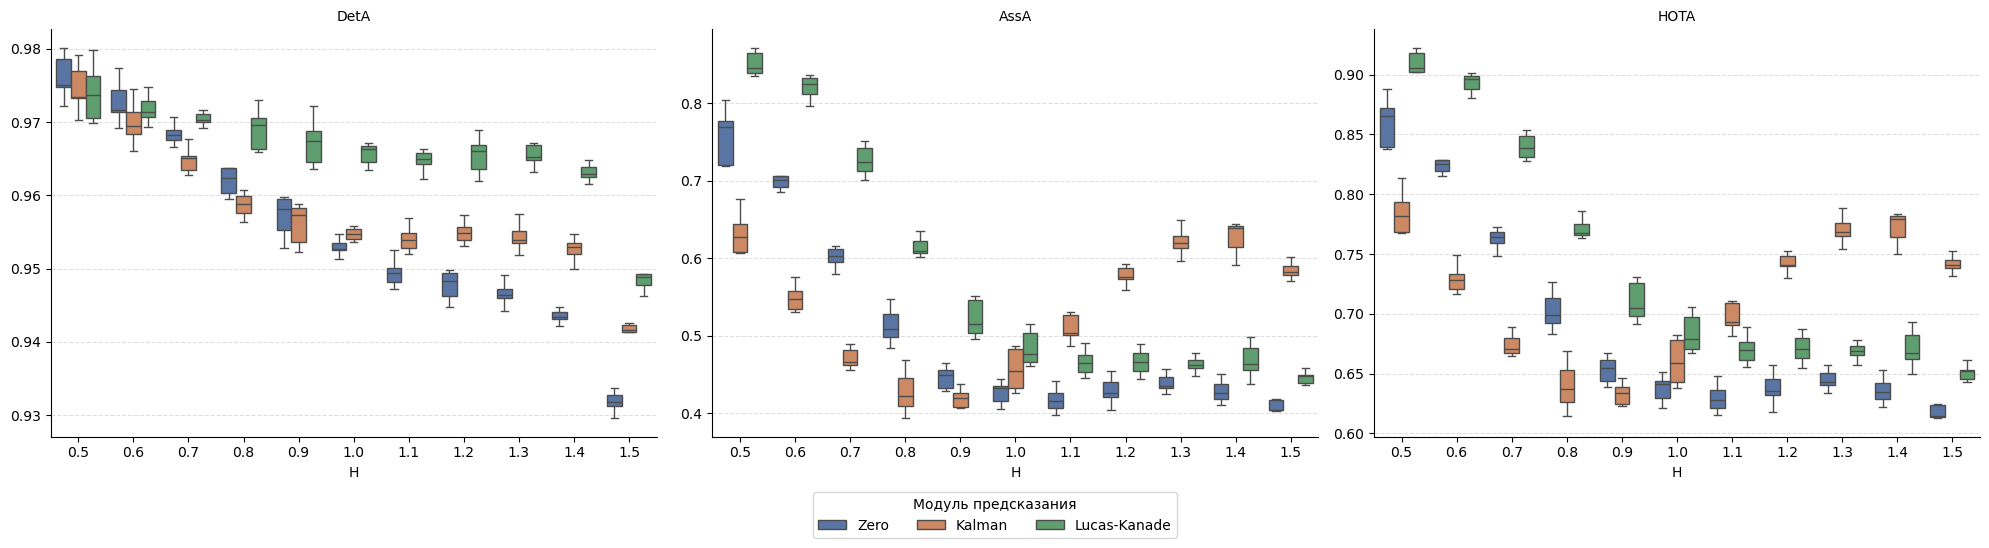

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

data = df_total[df_total.metric.isin(target_metrics)]
data['metric'] = data['metric'].replace({'assa_alpha':'AssA', 'deta_alpha':'DetA', 'hota_alpha':'HOTA'})
data['predhead'] = data['predhead'].replace({'zero':'Zero', 'kalman':'Kalman', 'lucas-kanade':'Lucas-Kanade'})

g = sns.catplot(
    data=data,
    x="hurst",
    y="value",
    hue="predhead",
    col="metric",
    kind="box",
    palette="deep",
    height=4,
    aspect=1.1,
    sharey=False,  
    legend_out=False,
    showfliers=False
)
g.figure.set_size_inches((20,5))
g.set_axis_labels("H", '')
g.set_titles("{col_name}") 
g.tick_params(axis="x")
g.despine()
g._legend.remove()
g.figure.legend(
    title="Модуль предсказания",
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.1)
)
for ax in g.axes.flat:
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)


plt.tight_layout()
g.figure.savefig('../data/artifacts/metrics/hurst_vs_predhead.png',
                 bbox_inches='tight',
                 dpi=300)

plt.show()
